<a href="https://colab.research.google.com/github/vadim13213/neural_networks/blob/main/new_2026_8.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%82%D0%B8%D0%B2%D0%BD%D0%BE-%D1%81%D0%BE%D1%81%D1%82%D1%8F%D0%B7%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F%20%D1%81%D0%B5%D1%82%D1%8C%20(GAN)/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%82%D0%B8%D0%B2%D0%BD%D0%BE_%D1%81%D0%BE%D1%81%D1%82%D1%8F%D0%B7%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D1%81%D0%B5%D1%82%D1%8C_(GAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №8. Генеративно-состязательная сеть (GAN)**

---
**❗ Примечание:**

Не забывайте периодически сохранять параметры модели. Функции для этого описаны в теоретической части. В случае приостановки процесса обучения из-за перегрузки ОЗУ, Вы сможете загрузить последние предобученные параметры и продолжить обучение.

---

## **Задание №1.** Обучите генератор воспризводить примитивные изображения. Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))





In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

import os
import random

from IPython import display

In [ ]:
os.makedirs("gan_generated_images", exist_ok=True)
os.makedirs("gan_saved_models", exist_ok=True)

Загрузка и подготовка данных

In [ ]:
# загрузка Fashion-MNIST
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# нормализация
x_train = x_train.astype("float32") / 127.5 - 1
# добавляю канал
x_train = np.expand_dims(x_train, axis=-1)

print(x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28, 1)


Должно быть (60000, 28, 28, 1)

Создание генератора

In [ ]:
noise_dim = 100


def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(noise_dim,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, 5, strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(
            1,
            5,
            strides=2,
            padding='same',
            use_bias=False,
            activation='tanh'
        )
    ])

    return model

Создание дискриминатора

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, 5, strides=2, padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])

    return model

Функции потерь

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss



def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

Создание моделей и оптимизаторов

In [ ]:
generator = build_generator()
discriminator = build_discriminator()


generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


generator.summary()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Подготовка датасета

In [ ]:
BATCH_SIZE = 256
BUFFER_SIZE = 60000
EPOCHS = 50

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

Один шаг обучения

In [ ]:
@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

Визуализация генерации

In [ ]:
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, noise_dim])


def generate_and_save_images(model, epoch, test_input):

    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2.0, cmap='gray')
        plt.axis('off')

    plt.savefig(f'gan_generated_images/image_at_epoch_{epoch:04d}.png')
    plt.show()

Цикл обучения

In [ ]:
def train(dataset, epochs):

    for epoch in range(1, epochs + 1):

        for image_batch in dataset:
            train_step(image_batch)

        display.clear_output(wait=True)

        generate_and_save_images(generator, epoch, seed)

        print(f'Epoch {epoch}/{epochs} completed')

        # Сохраняем модели каждые 10 эпох
        if epoch % 10 == 0:
            generator.save(
                f'gan_saved_models/generator_epoch_{epoch}.keras'
            )

            discriminator.save(
                f'gan_saved_models/discriminator_epoch_{epoch}.keras'
            )

Обучение

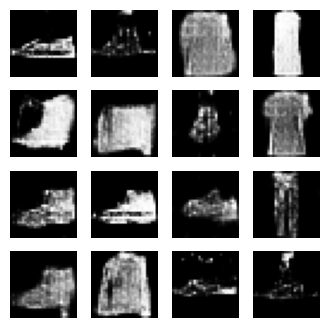

Epoch 50/50 completed


In [ ]:
train(train_dataset, EPOCHS)

### **Демонстрация сгенерированных изображений:**

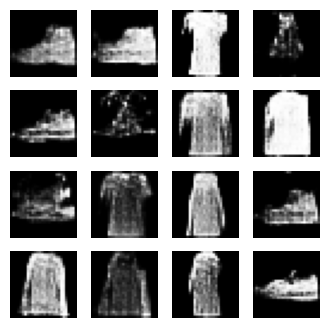

In [ ]:
noise = tf.random.normal([16, noise_dim])

generated_images = generator(noise, training=False)

plt.figure(figsize=(4, 4))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow((generated_images[i, :, :, 0] + 1) / 2.0, cmap='gray')
    plt.axis('off')

plt.show()

---

## **Задание №2.** Обучите генератор воспризводить примитивные изображения по заданному условию (Conditional Generative Adversarial Nets (CGAN)).



(На вход генератора подается вектор случайного шума и метка класса - на выходе должно получиться изображение, соответствующее данному классу)



Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))

Создание папок

In [ ]:
os.makedirs("cgan_generated_images", exist_ok=True)
os.makedirs("cgan_saved_models", exist_ok=True)

Загрузка данных

In [ ]:
(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Нормализация
x_train = (x_train.astype("float32") - 127.5) / 127.5

# Добавляем канал
x_train = np.expand_dims(x_train, axis=-1)

print("Images shape:", x_train.shape)
print("Labels shape:", y_train.shape)

Images shape: (60000, 28, 28, 1)
Labels shape: (60000,)


Что ожидать Images shape: (60000, 28, 28, 1)
Labels shape: (60000,)

Параметры модели

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256
EPOCHS = 50

noise_dim = 100
num_classes = 10

Создание Dataset

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

Генератор CGAN

In [ ]:
def build_generator():

    noise_input = layers.Input(shape=(noise_dim,))
    label_input = layers.Input(shape=(1,))

    # Embedding класса
    label_embedding = layers.Embedding(num_classes, 50)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # Объединяем шум и embedding
    model_input = layers.Concatenate()(
        [noise_input, label_embedding]
    )

    x = layers.Dense(7 * 7 * 256, use_bias=False)(model_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(
        128,
        5,
        strides=1,
        padding='same',
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(
        64,
        5,
        strides=2,
        padding='same',
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    output = layers.Conv2DTranspose(
        1,
        5,
        strides=2,
        padding='same',
        activation='tanh'
    )(x)

    model = tf.keras.Model(
        [noise_input, label_input],
        output
    )

    return model

Дискриминатор CGAN

In [ ]:
def build_discriminator():

    image_input = layers.Input(shape=(28, 28, 1))
    label_input = layers.Input(shape=(1,))

    # Embedding класса
    label_embedding = layers.Embedding(num_classes, 50)(label_input)
    label_embedding = layers.Dense(28 * 28)(label_embedding)

    label_embedding = layers.Reshape((28, 28, 1))(
        label_embedding
    )

    # Объединяем изображение и embedding
    x = layers.Concatenate(axis=-1)(
        [image_input, label_embedding]
    )

    x = layers.Conv2D(
        64,
        5,
        strides=2,
        padding='same'
    )(x)

    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(
        128,
        5,
        strides=2,
        padding='same'
    )(x)

    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    output = layers.Dense(1)(x)

    model = tf.keras.Model(
        [image_input, label_input],
        output
    )

    return model

Создание моделей

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        500 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12544)     │  1,881,600 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12544)     │     50,176 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 12544)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 256) │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 7, 7, 128) │    819,200 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 14, 14,    │    204,800 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 28, 28, 1) │      1,601 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,958,645 (11.29 MB)

 Trainable params: 2,933,173 (11.19 MB)

 Non-trainable params: 25,472 (99.50 KB)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        500 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 784)    │     39,984 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │      3,264 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 14,    │          0 │ leaky_re_lu_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 128) │    204,928 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 7, 7, 128) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 6272)      │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │      6,273 │ flatten_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 254,949 (995.89 KB)

 Trainable params: 254,949 (995.89 KB)

 Non-trainable params: 0 (0.00 B)

Функции потерь

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

Оптимизаторы

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

Один шаг обучения

In [ ]:
@tf.function
def train_step(images, labels):

    batch_size = tf.shape(images)[0]

    noise = tf.random.normal([batch_size, noise_dim])

    random_labels = tf.random.uniform(
        [batch_size, 1],
        minval=0,
        maxval=num_classes,
        dtype=tf.int32
    )

    labels = tf.cast(
        tf.reshape(labels, (-1, 1)),
        tf.int32
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(
            [noise, random_labels],
            training=True
        )

        real_output = discriminator(
            [images, labels],
            training=True
        )

        fake_output = discriminator(
            [generated_images, random_labels],
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

Визуализация результатов

In [ ]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

Функция генерации

In [ ]:
def generate_images_by_class(model, class_label):

    noise = tf.random.normal([16, noise_dim])

    labels = tf.constant(
        [[class_label]] * 16,
        dtype=tf.int32
    )

    generated_images = model(
        [noise, labels],
        training=False
    )

    plt.figure(figsize=(4, 4))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (generated_images[i, :, :, 0] + 1) / 2.0,
            cmap='gray'
        )

        plt.axis('off')

    plt.suptitle(
        f"Generated class: {class_names[class_label]}"
    )

    plt.show()

Цикл обучения

In [ ]:
def train(dataset, epochs):

    for epoch in range(epochs):

        for image_batch, label_batch in dataset:

            gen_loss, disc_loss = train_step(
                image_batch,
                label_batch
            )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Generator Loss: {gen_loss:.4f} | "
            f"Discriminator Loss: {disc_loss:.4f}"
        )

        # Сохраняем модели каждые 10 эпох
        if (epoch + 1) % 10 == 0:

            generator.save(
                f"cgan_saved_models/generator_epoch_{epoch+1}.keras"
            )

            discriminator.save(
                f"cgan_saved_models/discriminator_epoch_{epoch+1}.keras"
            )

Обучение

In [ ]:
train(train_dataset, EPOCHS)

Epoch 1/50 | Generator Loss: 0.8646 | Discriminator Loss: 1.2970
Epoch 2/50 | Generator Loss: 0.9124 | Discriminator Loss: 1.1297
Epoch 3/50 | Generator Loss: 0.7663 | Discriminator Loss: 1.3972
Epoch 4/50 | Generator Loss: 0.9913 | Discriminator Loss: 1.0984
Epoch 5/50 | Generator Loss: 0.7795 | Discriminator Loss: 1.2839
Epoch 6/50 | Generator Loss: 0.7385 | Discriminator Loss: 1.4438
Epoch 7/50 | Generator Loss: 0.8741 | Discriminator Loss: 1.1433
Epoch 8/50 | Generator Loss: 0.7691 | Discriminator Loss: 1.4075
Epoch 9/50 | Generator Loss: 0.8810 | Discriminator Loss: 1.3689
Epoch 10/50 | Generator Loss: 0.9846 | Discriminator Loss: 1.1295
Epoch 11/50 | Generator Loss: 0.9914 | Discriminator Loss: 1.0917
Epoch 12/50 | Generator Loss: 0.8437 | Discriminator Loss: 1.2187
Epoch 13/50 | Generator Loss: 0.9970 | Discriminator Loss: 1.1428
Epoch 14/50 | Generator Loss: 0.8490 | Discriminator Loss: 1.1690
Epoch 15/50 | Generator Loss: 1.3313 | Discriminator Loss: 0.8365
Epoch 16/50 | Gener

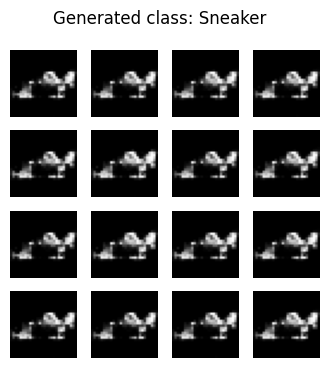

In [ ]:
generate_images_by_class(generator, 7)

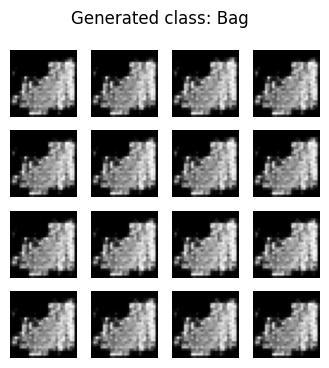

In [ ]:
generate_images_by_class(generator, 8)

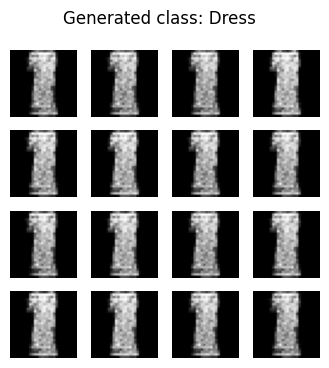

In [ ]:
generate_images_by_class(generator, 3)

### **Демонстрация сгенерированных изображений:**

In [ ]:
example_labels = [8, 7, 3, 0, 4, 5, 6, 7, 8, 9]
generate_images_by_labels(generator, example_labels)

---

## **Задание №3.** Обучите генератор колоризировать изображения из выбранного Вами датасета (можете использовать датасет из работы №6, в которой Вы решали аналогичную задачу).

Создание папок

In [ ]:
os.makedirs("colorization_results", exist_ok=True)
os.makedirs("colorization_models", exist_ok=True)

Загрузка CIFAR-10

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


Должно быть (50000, 32, 32, 3)
(10000, 32, 32, 3)

Нормализация

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Создание grayscale изображений

In [ ]:
x_train_gray = tf.image.rgb_to_grayscale(x_train)
x_test_gray = tf.image.rgb_to_grayscale(x_test)

print(x_train_gray.shape)

(50000, 32, 32, 1)


ожидаю (50000, 32, 32, 1)

Визуализация данных

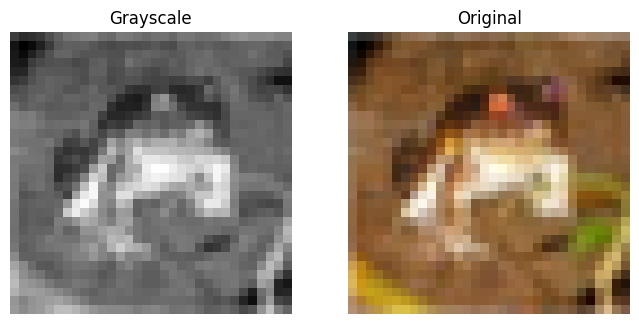

In [ ]:
plt.figure(figsize=(8,4))

# grayscale
plt.subplot(1,2,1)
plt.imshow(x_train_gray[0].numpy().squeeze(), cmap='gray')
plt.title("Grayscale")
plt.axis('off')

# original
plt.subplot(1,2,2)
plt.imshow(x_train[0])
plt.title("Original")
plt.axis('off')

plt.show()

Создание модели колоризации

In [ ]:
def build_colorization_model():

    inputs = layers.Input(shape=(32, 32, 1))

    # Encoder
    x = layers.Conv2D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(
        128,
        3,
        activation='relu',
        padding='same'
    )(x)

    x = layers.MaxPooling2D((2,2))(x)

    # Bottleneck
    x = layers.Conv2D(
        256,
        3,
        activation='relu',
        padding='same'
    )(x)

    # Decoder
    x = layers.UpSampling2D((2,2))(x)

    x = layers.Conv2D(
        128,
        3,
        activation='relu',
        padding='same'
    )(x)

    x = layers.UpSampling2D((2,2))(x)

    x = layers.Conv2D(
        64,
        3,
        activation='relu',
        padding='same'
    )(x)

    outputs = layers.Conv2D(
        3,
        3,
        activation='sigmoid',
        padding='same'
    )(x)

    model = Model(inputs, outputs)

    return model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

import numpy as np
import matplotlib.pyplot as plt

import random
import os

Создание модели

In [ ]:
model = build_colorization_model()

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,227 (2.82 MB)

 Trainable params: 740,227 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

Компиляция модели

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

Обучение

In [ ]:
history = model.fit(
    x_train_gray,
    x_train,
    validation_data=(x_test_gray, x_test),
    epochs=20,
    batch_size=128
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 56ms/step - loss: 0.0131 - mae: 0.0826 - val_loss: 0.0089 - val_mae: 0.0683
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - loss: 0.0082 - mae: 0.0644 - val_loss: 0.0079 - val_mae: 0.0642
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - loss: 0.0074 - mae: 0.0605 - val_loss: 0.0072 - val_mae: 0.0596
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0069 - mae: 0.0581 - val_loss: 0.0072 - val_mae: 0.0593
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0067 - mae: 0.0567 - val_loss: 0.0069 - val_mae: 0.0579
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0065 - mae: 0.0559 - val_loss: 0.0066 - val_mae: 0.0563
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0064 - mae: 0.0550 - val_loss: 0.0065 - val_mae: 0.0560
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0063 - mae: 0.0543 - val_loss: 0.0064 - val_mae: 0.0556
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
model.save("colorization_models/colorization_model.keras")

In [ ]:
predictions = model.predict(x_test_gray[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step


### **Демонстрация сгенерированных изображений:**

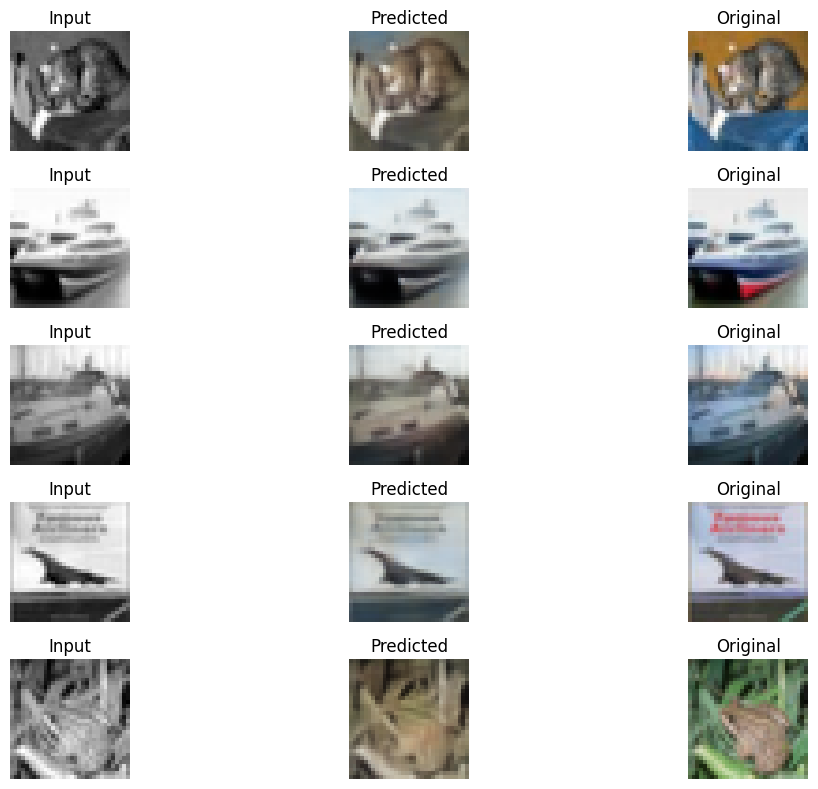

In [ ]:
n = 5

plt.figure(figsize=(12, 8))

for i in range(n):

    # grayscale
    ax = plt.subplot(n, 3, i * 3 + 1)

    plt.imshow(
        x_test_gray[i].numpy().squeeze(),
        cmap='gray'
    )

    plt.title("Input")
    plt.axis('off')

    # prediction
    ax = plt.subplot(n, 3, i * 3 + 2)

    plt.imshow(predictions[i])

    plt.title("Predicted")
    plt.axis('off')

    # original
    ax = plt.subplot(n, 3, i * 3 + 3)

    plt.imshow(x_test[i])

    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

---

## **Задание №4.** Обучите генератор воспроизводить изображения из выбранного Вами датасета (pix2pix).



---
Примеры таких датасетов представлены на сайтах [kaggle.com](https://www.kaggle.com/search?q=pix2pix+in%3Adatasets+datasetFileTypes%3Ajpg+datasetFileTypes%3Apng) и [efrosgans.eecs.berkeley.edu*](http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/).

**\*Калифорнийский университет Беркли (UC Berkeley) внесён в реестр организаций, деятельность которых признана нежелательной в России.**


---

создание папок

In [ ]:
os.makedirs("pix2pix_results", exist_ok=True)
os.makedirs("pix2pix_models", exist_ok=True)

Загрузка CIFAR-10

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Создание grayscale изображений

In [ ]:
x_train_gray = tf.image.rgb_to_grayscale(x_train)
x_test_gray = tf.image.rgb_to_grayscale(x_test)

Dataset

In [ ]:
BUFFER_SIZE = 50000
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train_gray, x_train)
)

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

Generator (U-Net)

In [ ]:
def build_generator():

    inputs = layers.Input(shape=(32, 32, 1))

    # Encoder
    down1 = layers.Conv2D(
        64,
        4,
        strides=2,
        padding='same',
        activation='relu'
    )(inputs)

    down2 = layers.Conv2D(
        128,
        4,
        strides=2,
        padding='same',
        activation='relu'
    )(down1)

    # Bottleneck
    bottleneck = layers.Conv2D(
        256,
        4,
        strides=2,
        padding='same',
        activation='relu'
    )(down2)

    # Decoder
    up1 = layers.Conv2DTranspose(
        128,
        4,
        strides=2,
        padding='same',
        activation='relu'
    )(bottleneck)

    up1 = layers.Concatenate()([up1, down2])

    up2 = layers.Conv2DTranspose(
        64,
        4,
        strides=2,
        padding='same',
        activation='relu'
    )(up1)

    up2 = layers.Concatenate()([up2, down1])

    outputs = layers.Conv2DTranspose(
        3,
        4,
        strides=2,
        padding='same',
        activation='sigmoid'
    )(up2)

    return tf.keras.Model(inputs, outputs)

Discriminator (PatchGAN)

In [ ]:
def build_discriminator():

    input_image = layers.Input(shape=(32, 32, 1))
    target_image = layers.Input(shape=(32, 32, 3))

    x = layers.Concatenate()([input_image, target_image])

    x = layers.Conv2D(
        64,
        4,
        strides=2,
        padding='same'
    )(x)

    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(
        128,
        4,
        strides=2,
        padding='same'
    )(x)

    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(
        256,
        4,
        strides=2,
        padding='same'
    )(x)

    x = layers.LeakyReLU()(x)

    outputs = layers.Conv2D(
        1,
        4,
        padding='same'
    )(x)

    return tf.keras.Model(
        [input_image, target_image],
        outputs
    )

Создание моделей

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │      1,088 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 8, 128) │    131,200 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 4, 4, 256) │    524,544 │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 8, 8, 128) │    524,416 │ conv2d_18[0][0]   │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 256) │          0 │ conv2d_transpose… │
│ (Concatenate)       │                   │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 16, 16,    │    262,208 │ concatenate_2[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 32, 32, 3) │      6,147 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,449,603 (5.53 MB)

 Trainable params: 1,449,603 (5.53 MB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32, 4) │          0 │ input_layer_9[0]… │
│ (Concatenate)       │                   │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │      4,160 │ concatenate_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 16, 16,    │          0 │ conv2d_19[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 8, 8, 128) │    131,200 │ leaky_re_lu_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 8, 8, 128) │          0 │ conv2d_20[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 4, 4, 256) │    524,544 │ leaky_re_lu_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 4, 4, 256) │          0 │ conv2d_21[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 4, 4, 1)   │      4,097 │ leaky_re_lu_12[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 664,001 (2.53 MB)

 Trainable params: 664,001 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

Loss functions

In [ ]:
loss_object = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

LAMBDA = 100

Генератор loss

In [ ]:
def generator_loss(
    disc_generated_output,
    gen_output,
    target
):

    gan_loss = loss_object(
        tf.ones_like(disc_generated_output),
        disc_generated_output
    )

    l1_loss = tf.reduce_mean(
        tf.abs(target - gen_output)
    )

    total_gen_loss = gan_loss + (LAMBDA * l1_loss)

    return total_gen_loss

Дескриминатор loss

In [ ]:
def discriminator_loss(
    disc_real_output,
    disc_generated_output
):

    real_loss = loss_object(
        tf.ones_like(disc_real_output),
        disc_real_output
    )

    generated_loss = loss_object(
        tf.zeros_like(disc_generated_output),
        disc_generated_output
    )

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

Оптимизатор

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(
    2e-4,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    2e-4,
    beta_1=0.5
)

Шаг обучения

In [ ]:
@tf.function
def train_step(input_image, target):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        gen_output = generator(
            input_image,
            training=True
        )

        disc_real_output = discriminator(
            [input_image, target],
            training=True
        )

        disc_generated_output = discriminator(
            [input_image, gen_output],
            training=True
        )

        gen_loss = generator_loss(
            disc_generated_output,
            gen_output,
            target
        )

        disc_loss = discriminator_loss(
            disc_real_output,
            disc_generated_output
        )

    generator_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

Обучение

In [ ]:
EPOCHS = 20

for epoch in range(EPOCHS):

    for input_image, target in train_dataset:

        gen_loss, disc_loss = train_step(
            input_image,
            target
        )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Gen Loss: {gen_loss:.4f} | "
        f"Disc Loss: {disc_loss:.4f}"
    )

Epoch 1/20 | Gen Loss: 9.5512 | Disc Loss: 0.8064
Epoch 2/20 | Gen Loss: 8.9919 | Disc Loss: 0.6318
Epoch 3/20 | Gen Loss: 8.5635 | Disc Loss: 0.4704
Epoch 4/20 | Gen Loss: 10.0989 | Disc Loss: 0.3656
Epoch 5/20 | Gen Loss: 8.6680 | Disc Loss: 0.5987
Epoch 6/20 | Gen Loss: 8.0460 | Disc Loss: 0.6059
Epoch 7/20 | Gen Loss: 8.1660 | Disc Loss: 0.6511
Epoch 8/20 | Gen Loss: 11.9297 | Disc Loss: 0.6481
Epoch 9/20 | Gen Loss: 7.2830 | Disc Loss: 0.5927
Epoch 10/20 | Gen Loss: 7.8877 | Disc Loss: 0.4432
Epoch 11/20 | Gen Loss: 7.7025 | Disc Loss: 0.8424
Epoch 12/20 | Gen Loss: 6.6737 | Disc Loss: 0.6926
Epoch 13/20 | Gen Loss: 9.2817 | Disc Loss: 0.8870
Epoch 14/20 | Gen Loss: 7.2721 | Disc Loss: 0.7965
Epoch 15/20 | Gen Loss: 7.3227 | Disc Loss: 0.7478
Epoch 16/20 | Gen Loss: 6.3746 | Disc Loss: 1.1152
Epoch 17/20 | Gen Loss: 6.6121 | Disc Loss: 0.7908
Epoch 18/20 | Gen Loss: 9.6548 | Disc Loss: 0.2347
Epoch 19/20 | Gen Loss: 14.0533 | Disc Loss: 0.1896
Epoch 20/20 | Gen Loss: 7.2472 | Disc

Сохранение моделей

In [ ]:
generator.save("pix2pix_models/generator.keras")
discriminator.save("pix2pix_models/discriminator.keras")

предсказание

In [ ]:
sample_input = x_test_gray[:5]

predictions = generator(
    sample_input,
    training=False
)

### **Демонстрация сгенерированных изображений:**

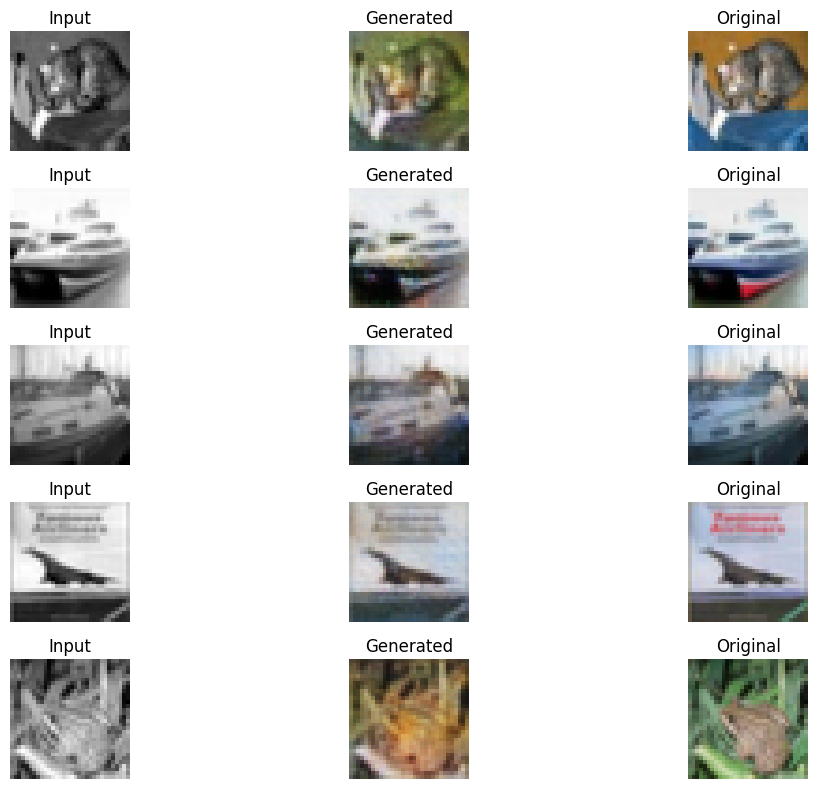

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(5):

    # input
    plt.subplot(5, 3, i * 3 + 1)

    plt.imshow(
        sample_input[i].numpy().squeeze(),
        cmap='gray'
    )

    plt.title("Input")
    plt.axis('off')

    # generated
    plt.subplot(5, 3, i * 3 + 2)

    plt.imshow(predictions[i])

    plt.title("Generated")
    plt.axis('off')

    # original
    plt.subplot(5, 3, i * 3 + 3)

    plt.imshow(x_test[i])

    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!zip -r gan_saved_models.zip gan_saved_models

  adding: gan_saved_models/ (stored 0%)
  adding: gan_saved_models/discriminator_epoch_40.keras (deflated 10%)
  adding: gan_saved_models/discriminator_epoch_50.keras (deflated 10%)
  adding: gan_saved_models/discriminator_epoch_10.keras (deflated 10%)
  adding: gan_saved_models/generator_epoch_10.keras (deflated 8%)
  adding: gan_saved_models/generator_epoch_50.keras (deflated 8%)
  adding: gan_saved_models/generator_epoch_30.keras (deflated 8%)
  adding: gan_saved_models/discriminator_epoch_20.keras (deflated 10%)
  adding: gan_saved_models/generator_epoch_20.keras (deflated 8%)
  adding: gan_saved_models/discriminator_epoch_30.keras (deflated 10%)
  adding: gan_saved_models/generator_epoch_40.keras (deflated 8%)


In [ ]:
!zip -r cgan_saved_models.zip cgan_saved_models

  adding: cgan_saved_models/ (stored 0%)
  adding: cgan_saved_models/discriminator_epoch_40.keras (deflated 11%)
  adding: cgan_saved_models/discriminator_epoch_50.keras (deflated 11%)
  adding: cgan_saved_models/discriminator_epoch_10.keras (deflated 11%)
  adding: cgan_saved_models/generator_epoch_10.keras (deflated 8%)
  adding: cgan_saved_models/generator_epoch_50.keras (deflated 8%)
  adding: cgan_saved_models/generator_epoch_30.keras (deflated 8%)
  adding: cgan_saved_models/discriminator_epoch_20.keras (deflated 11%)
  adding: cgan_saved_models/generator_epoch_20.keras (deflated 8%)
  adding: cgan_saved_models/discriminator_epoch_30.keras (deflated 11%)
  adding: cgan_saved_models/generator_epoch_40.keras (deflated 8%)


In [ ]:
!zip -r pix2pix_models.zip pix2pix_models

  adding: pix2pix_models/ (stored 0%)
  adding: pix2pix_models/generator.keras (deflated 8%)
  adding: pix2pix_models/discriminator.keras (deflated 8%)


In [ ]:
!zip -r colorization_models.zip colorization_models

  adding: colorization_models/ (stored 0%)
  adding: colorization_models/colorization_model.keras (deflated 8%)
